In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts

plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100
nua = np.load('nua.npy')
dnu = np.arange(N)*dnuc

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]


k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont 

# binning 
NB = 64  # number of bins


In [3]:
INP_SIGNAL_CONFIGS = {
    "21cm": dict(type="21cm"),
    "FG+21cm": dict(type="FG+21cm"),
    "FG+MM+21cm": dict(type="FG+MM+21cm"),
}


# -----------------------------
# FLAG configurations
# -----------------------------
FLAG_CONFIGS = {
    "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
    "RANDOM35": dict(mode="RANDOM", percent=35, seed=42),
    "PERIODIC": dict(mode="PERIODIC", percent=0, seed=42),
    "PERIODIC+RANDOM10": dict(mode="PERIODIC+RANDOM", percent=10, seed=42),
}



In [4]:
inp_signal = '21cm'
# fields_21cm = generate_fields(inp_signal=inp_signal, N=N, Nrea=Nrea, P_dft=P_dft)
fields_21cm = np.array(
        [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
    )
np.save('21cm.npy', fields_21cm)


In [5]:
fields_forg1 = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e4,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1,
        )

np.save('FG+21cm.npy', fields_forg1)


fields_forg2 = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e2,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1,
        )

np.save('FG+MM+21cm.npy', fields_forg2)

/home/asif/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:523: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


In [6]:
for flag_key, flag_cfg in FLAG_CONFIGS.items():

    flag = pfunc.flagdata(
        N,
        mode=flag_cfg["mode"],
        percent=flag_cfg["percent"],
        seed=flag_cfg["seed"],
    )
    
    np.save(f'{flag_cfg["mode"]}.npy',flag)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Length scales
ell1 = 1e4*dnuc   # smooth FG
ell2 = 1e2*dnuc   # structured FG

# RBF covariance (normalised)
K1 = 1e0 * np.exp(-0.5 * (dnu / ell1)**2)
K2 = 1e0 * np.exp(-0.5 * (dnu / ell2)**2)


from sklearn.gaussian_process.kernels import RBF

def get_kernel_matrix(Npoints, amplitude, length_scale, dnuc):
    x = np.arange(Npoints)[:, None]*dnuc
    kernel = amplitude * RBF(length_scale=length_scale)
    K = kernel(x, x)   # this is the covariance matrix
    return K


amplitude = 1e0
K1 = get_kernel_matrix(N, amplitude, ell1, dnuc) # 1e0 * RBF(length_scale=ell1)
K2 = get_kernel_matrix(N, amplitude, ell2, dnuc) # 1e0 * RBF(length_scale=ell2)


In [8]:
from scipy import integrate
def pk_intp(kv, karr, pkarr): # kv, k-array , pk-array
    y = np.interp(np.log(kv), np.log(karr), np.log(pkarr))
    return np.exp(y) # np.interp(kv, karr, pkarr)


def pk2cl(x, rp, dn, kp, dnuc, karr, pkarr): # x: kpara-array, dn: ndnu, kp:kper, dnuc:dnuc.
    kv = np.sqrt(kp**2 + x**2)
    y = np.cos(x*rp*dn) * pk_intp(kv, karr, pkarr) * np.power(np.sinc(x*rp*dnuc/(2.*np.pi)), 2.) 
    # less than 1% change at dnu=0 when sinc is omitted.
    return y

    
cl21 = np.zeros(N)
x = np.linspace(0, 5, 2*N)
for jj in range(N):
    cl21[jj] = integrate.simpson(pk2cl(x, rp, dnu[jj], 0., dnuc, k_model, P_model), x)/(np.pi*r**2)

cl_norm = cl21/cl21[0]
# plt.plot(cl_norm)
# plt.show()

from scipy.linalg import toeplitz
COV21 = toeplitz(cl_norm)

# plt.pcolormesh(dnu, dnu, COV21)
# plt.show()


/tmp/ipykernel_3867189/1844979591.py:3: RuntimeWarning: divide by zero encountered in log
  y = np.interp(np.log(kv), np.log(karr), np.log(pkarr))


In [9]:
# import numpy as np
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(
#     1, 3,
#     figsize=(14, 5),
#     sharey=True,
#     constrained_layout=True
# )

# # -----------------------------
# # Covariance matrices
# # -----------------------------
# pcm0 = axes[0].pcolormesh(dnu, dnu, COV21, shading='auto', rasterized=True)
# pcm1 = axes[1].pcolormesh(dnu, dnu, K1,    shading='auto', rasterized=True)
# pcm2 = axes[2].pcolormesh(dnu, dnu, K2,    shading='auto', rasterized=True)

# # -----------------------------
# # Column titles
# # -----------------------------
# axes[0].set_title(r'\rm{EoR\ 21-cm\ signal}', pad=6)
# axes[1].set_title(r'\rm{Spectrally\ smooth\ foreground\ signal}', pad=6)

# axes[2].set_title(
#     r'\rm{Foregrounds\ with\ spectral\ structure}' + '\n' +
#     r'\rm{(mode-mixing\ signal)}',
#     pad=6
# )

# # -----------------------------
# # Axes labels
# # -----------------------------
# for ax in axes:
#     ax.set_xlabel(r'$\rm{\Delta\nu\ MHz}$')
#     ax.set_aspect('equal')

# axes[0].set_ylabel(r'$\rm{\Delta\nu\ MHz}$')

# # -----------------------------
# # Colorbar
# # -----------------------------
# cbar = fig.colorbar(pcm2, ax=axes, pad=0.02, shrink=0.7)
# cbar.set_label(r'$\rm{Covariance}$')

# # -----------------------------
# # Save
# # -----------------------------
# plt.savefig('plots/fg_eor_covariances.pdf', bbox_inches='tight')
# plt.show()


In [10]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --------------------------------------------------
# # Controls
# # --------------------------------------------------
# nplot = 5
# lw_main = 2
# lw_sec  = 1
# alpha_sec = 0.5

# freq = np.load('nua.npy') / 1e6  # MHz
# rng  = np.random.default_rng(42)
# idx  = rng.choice(Nrea, size=nplot, replace=False)

# # --------------------------------------------------
# # Figure layout: 2 rows × 3 columns
# # --------------------------------------------------
# fig, axes = plt.subplots(
#     2, 3,
#     figsize=(14, 8),
#     constrained_layout=True
# )

# # ==================================================
# # Column titles (ONLY once, top row)
# # ==================================================
# axes[0, 0].set_title(r'\rm{EoR\ 21-cm\ signal}')
# axes[0, 1].set_title(r'$\rm{Spectrally\ smooth\ foreground\ signal}$')
# axes[0, 2].set_title(
#     r'\rm{Foregrounds\ with\ spectral\ structure}' + '\n' +
#     r'\rm{(mode-mixing\ signal)}'
# )

# # ==================================================
# # TOP ROW: Covariance vs Δν
# # ==================================================
# Kdiag_smooth = K1[0, :]
# Kdiag_struct = K2[0, :]

# axes[0, 0].plot(dnu, cl_norm, lw=2)
# axes[0, 1].plot(dnu, Kdiag_smooth / Kdiag_smooth[0], lw=2)
# axes[0, 2].plot(dnu, Kdiag_struct / Kdiag_struct[0], lw=2)

# for j in range(3):
#     axes[0, j].set_xlabel(r'$\rm{\Delta\nu\ MHz}$')
# axes[0, 0].set_ylabel(r'$\rm{Normalised\ covariance}$')

# # ==================================================
# # BOTTOM ROW: Random realisations
# # ==================================================
# # (a) 21-cm
# for k, i in enumerate(idx):
#     lw = lw_main if k == 0 else lw_sec
#     alpha = 1.0 if k == 0 else alpha_sec
#     axes[1, 0].plot(freq, fields_21cm[i], lw=lw, alpha=alpha)

# axes[1, 0].set_ylabel(r'$\rm{\delta T_{21}(\nu)}$'+r'\rm{(arbitrary\ units)}')

# # (b) Smooth FG
# for k, i in enumerate(idx):
#     lw = lw_main if k == 0 else lw_sec
#     alpha = 1.0 if k == 0 else alpha_sec
#     fg = fields_forg1[i]
#     axes[1, 1].plot(freq, fg / fg[N//2], lw=lw, alpha=alpha)

# axes[1, 1].set_ylabel(r'$\rm{T_{FG}(\nu)/T_{FG}(\nu_c)}$')

# # (c) Structured FG
# for k, i in enumerate(idx):
#     lw = lw_main if k == 0 else lw_sec
#     alpha = 1.0 if k == 0 else alpha_sec
#     fg = fields_forg2[i] / 1e6
#     axes[1, 2].plot(freq, fg, lw=lw, alpha=alpha)

# axes[1, 2].set_ylabel(r'$\rm{T_{MM}(\nu)\ (arbitrary\ units)}$')

# for j in range(3):
#     axes[1, j].set_xlabel(r'$\rm{\nu\ MHz}$')

# # --------------------------------------------------
# # Save
# # --------------------------------------------------
# fig.align_ylabels()

# plt.savefig('plots/fg_eor_correlations_realisations.pdf', bbox_inches='tight')
# plt.show()


In [11]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --------------------------------------------------
# # Controls
# # --------------------------------------------------
# nplot = 5
# lw_main = 2
# lw_sec  = 1
# alpha_sec = 0.5

# freq = np.load('nua.npy') / 1e6  # MHz
# rng  = np.random.default_rng(42)
# idx  = rng.choice(Nrea, size=nplot, replace=False)

# # --------------------------------------------------
# # Figure layout: 3 rows × 4 columns (last for colorbar)
# # --------------------------------------------------
# fig = plt.figure(figsize=(14, 11), constrained_layout=True)

# gs = fig.add_gridspec(
#     3, 4,
#     width_ratios=[1, 1, 1, 0.04],
#     height_ratios=[1.3, 0.9, 1.0],
#     wspace=0.08,
#     hspace=0.10
# )

# axes = np.empty((3, 3), dtype=object)
# for i in range(3):
#     for j in range(3):
#         axes[i, j] = fig.add_subplot(gs[i, j])

# # ==================================================
# # ROW 1: Covariance matrices
# # ==================================================
# pcm0 = axes[0, 0].pcolormesh(dnu, dnu, COV21, shading='auto', rasterized=True)
# pcm1 = axes[0, 1].pcolormesh(dnu, dnu, K1,    shading='auto', rasterized=True)
# pcm2 = axes[0, 2].pcolormesh(dnu, dnu, K2,    shading='auto', rasterized=True)

# # Column titles (ONLY here)
# axes[0, 0].set_title(r'\rm{EoR\ 21-cm\ signal}', pad=6)
# axes[0, 1].set_title(r'\rm{Spectrally\ smooth\ foreground\ signal}', pad=6)
# axes[0, 2].set_title(
#     r'\rm{Foregrounds\ with\ spectral\ structure}' + '\n' +
#     r'\rm{(mode-mixing\ signal)}',
#     pad=6
# )

# for j in range(3):
#     axes[0, j].set_xlabel(r'$\rm{\Delta\nu\ [MHz]}$')
#     axes[0, j].set_ylabel(r'$\rm{\Delta\nu\ [MHz]}$')
#     axes[0, j].set_aspect('equal')

# # Colorbar (dedicated column)
# cax = fig.add_subplot(gs[0, 3])
# cbar = fig.colorbar(pcm2, cax=cax)
# cbar.set_label(r'$\rm{Covariance}$')

# # ==================================================
# # ROW 2: Normalised covariance vs Δν
# # ==================================================
# Kdiag_smooth = K1[0, :]
# Kdiag_struct = K2[0, :]

# axes[1, 0].plot(dnu, cl_norm, lw=2)
# axes[1, 1].plot(dnu, Kdiag_smooth / Kdiag_smooth[0], lw=2)
# axes[1, 2].plot(dnu, Kdiag_struct / Kdiag_struct[0], lw=2)

# for j in range(3):
#     axes[1, j].set_xlabel(r'$\rm{\Delta\nu\ MHz}$')
#     axes[1, j].set_ylabel(r'$\rm{Normalised\ covariance}$')

# # ==================================================
# # ROW 3: Random realisations
# # ==================================================
# # (a) 21-cm
# for k, i in enumerate(idx):
#     lw = lw_main if k == 0 else lw_sec
#     alpha = 1.0 if k == 0 else alpha_sec
#     axes[2, 0].plot(freq, fields_21cm[i], lw=lw, alpha=alpha)

# axes[2, 0].set_ylabel(
#     r'$\rm{\delta T_{21}(\nu)}$' + r'\rm{\ (arbitrary\ units)}'
# )

# # (b) Smooth FG
# for k, i in enumerate(idx):
#     lw = lw_main if k == 0 else lw_sec
#     alpha = 1.0 if k == 0 else alpha_sec
#     fg = fields_forg1[i]
#     axes[2, 1].plot(freq, fg / fg[N//2], lw=lw, alpha=alpha)

# axes[2, 1].set_ylabel(r'$\rm{T_{FG}(\nu)/T_{FG}(\nu_c)}$')

# # (c) Structured FG
# for k, i in enumerate(idx):
#     lw = lw_main if k == 0 else lw_sec
#     alpha = 1.0 if k == 0 else alpha_sec
#     fg = fields_forg2[i] / 1e6
#     axes[2, 2].plot(freq, fg, lw=lw, alpha=alpha)

# axes[2, 2].set_ylabel(
#     r'$\rm{T_{MM}(\nu)\ (arbitrary\ units)}$'
# )

# for j in range(3):
#     axes[2, j].set_xlabel(r'$\rm{\nu\ MHz}$')

# # --------------------------------------------------
# # Save
# # --------------------------------------------------
# fig.align_ylabels()
# plt.savefig('plots/fg_eor_cov_realizations.pdf', bbox_inches='tight')
# plt.show()


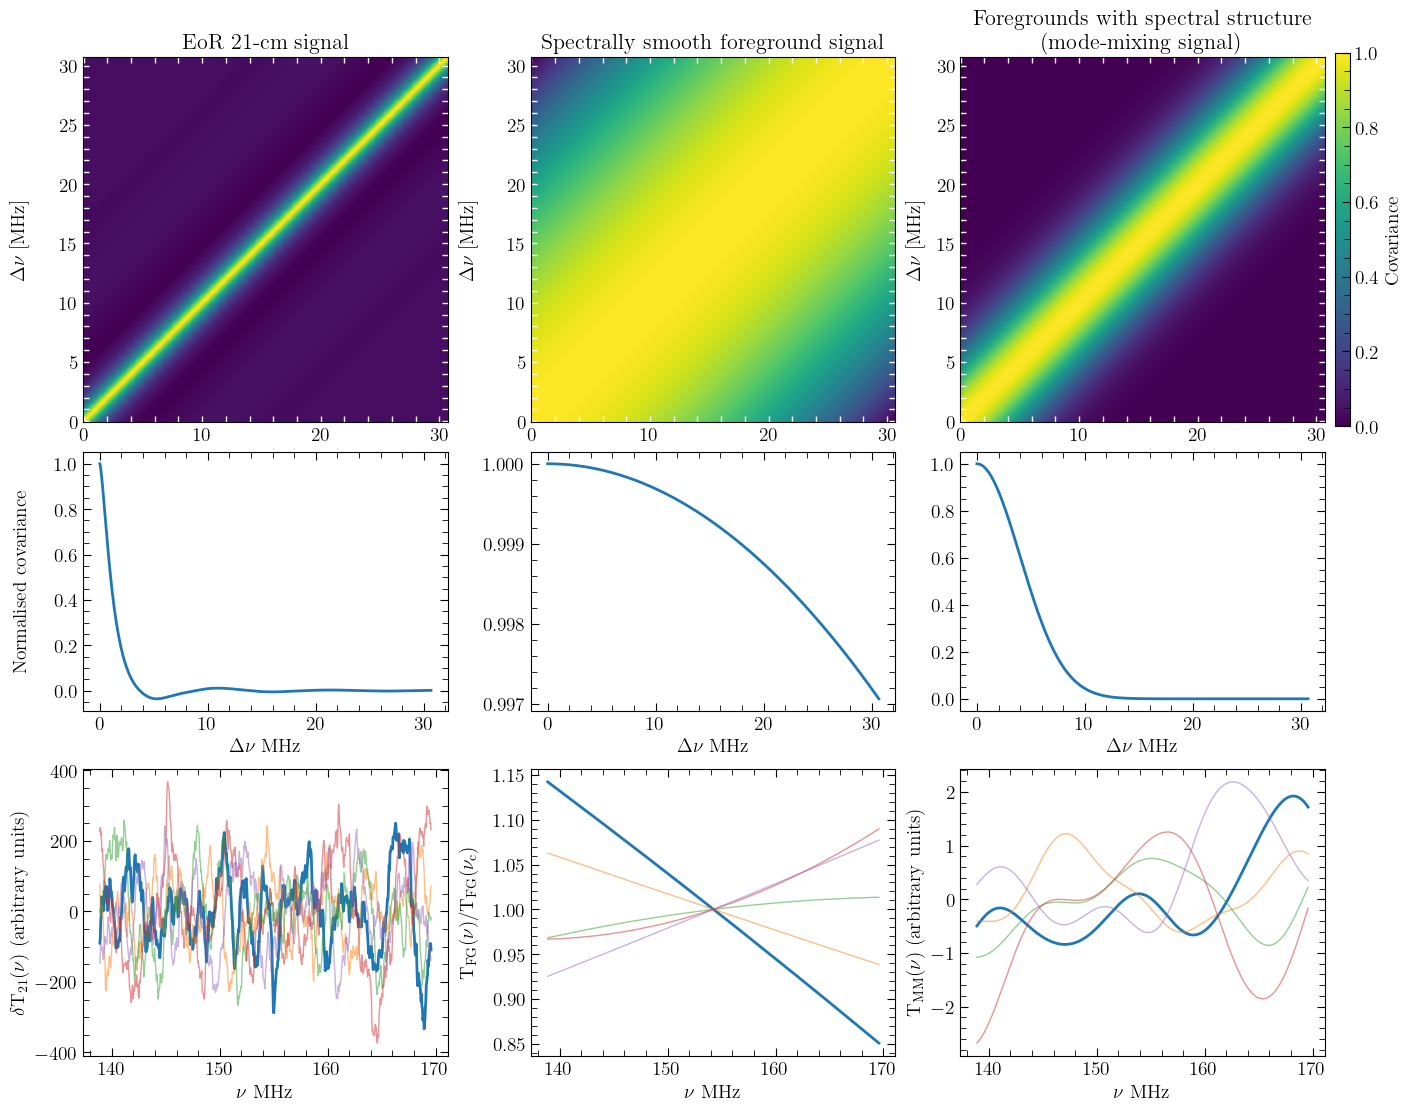

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Controls
# --------------------------------------------------
nplot = 5
lw_main = 2
lw_sec  = 1
alpha_sec = 0.5

freq = np.load('nua.npy') / 1e6  # MHz
rng  = np.random.default_rng(42)
idx  = rng.choice(Nrea, size=nplot, replace=False)

# --------------------------------------------------
# Figure layout: 3 rows × 4 columns (last for colorbar)
# --------------------------------------------------
fig = plt.figure(figsize=(14, 11), constrained_layout=True)

gs = fig.add_gridspec(
    3, 4,
    width_ratios=[1, 1, 1, 0.04],
    height_ratios=[1.3, 0.9, 1.0],
    wspace=0.01,
    hspace=0.01
)


# axes = np.empty((3, 3), dtype=object)

# for j in range(3):
#     # Row 0: independent (top row)
#     axes[0, j] = fig.add_subplot(gs[0, j])

#     # Row 1: share x with row 0 (same column)
#     axes[1, j] = fig.add_subplot(gs[1, j], sharex=axes[0, j])

#     # Row 2: independent (different physical x-axis: ν)
#     axes[2, j] = fig.add_subplot(gs[2, j])


axes = np.empty((3, 3), dtype=object)
for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

# ==================================================
# ROW 1: Covariance matrices
# ==================================================
pcm0 = axes[0, 0].pcolormesh(dnu, dnu, COV21, shading='auto', rasterized=True)
pcm1 = axes[0, 1].pcolormesh(dnu, dnu, K1,    shading='auto', rasterized=True)
pcm2 = axes[0, 2].pcolormesh(dnu, dnu, K2,    shading='auto', rasterized=True)

# Column titles (ONLY here)
axes[0, 0].set_title(r'\rm{EoR\ 21-cm\ signal}', pad=6)
axes[0, 1].set_title(r'\rm{Spectrally\ smooth\ foreground\ signal}', pad=6)
axes[0, 2].set_title(
    r'\rm{Foregrounds\ with\ spectral\ structure}' + '\n' +
    r'\rm{(mode-mixing\ signal)}',
    pad=6
)

for j in range(3):
    # axes[0, j].set_xlabel(r'$\rm{\Delta\nu\ [MHz]}$')
    axes[0, j].set_ylabel(r'$\rm{\Delta\nu\ [MHz]}$')
    axes[0, j].set_aspect('equal')

# Colorbar (dedicated column)
cax = fig.add_subplot(gs[0, 3])
cbar = fig.colorbar(pcm2, cax=cax)
cbar.set_label(r'$\rm{Covariance}$')


for j in range(3):
    axes[0, j].tick_params(
        axis='both',
        which='both',
        color='white',   # tick marks
        labelcolor='k',
        width=1.0,
        length=4
    )




# ==================================================
# ROW 2: Normalised covariance vs Δν
# ==================================================
Kdiag_smooth = K1[0, :]
Kdiag_struct = K2[0, :]

axes[1, 0].plot(dnu, cl_norm, lw=2)
axes[1, 1].plot(dnu, Kdiag_smooth / Kdiag_smooth[0], lw=2)
axes[1, 2].plot(dnu, Kdiag_struct / Kdiag_struct[0], lw=2)

for j in range(3):
    axes[1, j].set_xlabel(r'$\rm{\Delta\nu\ MHz}$')
axes[1, 0].set_ylabel(r'$\rm{Normalised\ covariance}$')


# dnu_marks = [5, 10, 15, 20, 25, 30]  # MHz (choose what matters)

# for j in range(3):
#     for nu in dnu_marks:
#         axes[0, j].axvline(
#             nu, color='k', lw=0.6, alpha=0.4, zorder=3
#         )
#         axes[0, j].axhline(
#             nu, color='k', lw=0.6, alpha=0.4, zorder=3
#         )





# ==================================================
# ROW 3: Random realisations
# ==================================================
# (a) 21-cm
for k, i in enumerate(idx):
    lw = lw_main if k == 0 else lw_sec
    alpha = 1.0 if k == 0 else alpha_sec
    axes[2, 0].plot(freq, fields_21cm[i], lw=lw, alpha=alpha)

axes[2, 0].set_ylabel(
    r'$\rm{\delta T_{21}(\nu)}$' + r'\rm{\ (arbitrary\ units)}'
)

# (b) Smooth FG
for k, i in enumerate(idx):
    lw = lw_main if k == 0 else lw_sec
    alpha = 1.0 if k == 0 else alpha_sec
    fg = fields_forg1[i]
    axes[2, 1].plot(freq, fg / fg[N//2], lw=lw, alpha=alpha)

axes[2, 1].set_ylabel(r'$\rm{T_{FG}(\nu)/T_{FG}(\nu_c)}$')

# (c) Structured FG
for k, i in enumerate(idx):
    lw = lw_main if k == 0 else lw_sec
    alpha = 1.0 if k == 0 else alpha_sec
    fg = fields_forg2[i] / 1e6
    axes[2, 2].plot(freq, fg, lw=lw, alpha=alpha)

axes[2, 2].set_ylabel(
    r'$\rm{T_{MM}(\nu)\ (arbitrary\ units)}$'
)

for j in range(3):
    axes[2, j].set_xlabel(r'$\rm{\nu\ MHz}$')

# --------------------------------------------------
# Save
# --------------------------------------------------
fig.align_ylabels()
plt.savefig('plots/fg_eor_cov_realizations.pdf', bbox_inches='tight')
plt.show()
